In [1]:
# ===============================
# Heart Disease Prediction Project
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Load Dataset
data = pd.read_csv("heart.csv")

print(data.head())
print(data.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [4]:
# Rename Columns

data.rename(columns={
    "age":"Age",
    "sex":"Gender",
    "cp":"ChestPainType",
    "trestbps":"RestingBp",
    "chol":"Cholesterol",
    "fbs":"FastingBs",
    "restecg":"RestingECG",
    "thalach":"MaxHR",
    "exang":"ExerciseAngina",
    "oldpeak":"ST_Depression",
    "slope":"ST_Slope",
    "ca":"MajorVessels",
    "thal":"Thalassemia",
    "target":"HeartDisease"
}, inplace=True)

print(data.head())

   Age  Gender  ChestPainType  RestingBp  Cholesterol  FastingBs  RestingECG  \
0   63       1              3        145          233          1           0   
1   37       1              2        130          250          0           1   
2   41       0              1        130          204          0           0   
3   56       1              1        120          236          0           1   
4   57       0              0        120          354          0           1   

   MaxHR  ExerciseAngina  ST_Depression  ST_Slope  MajorVessels  Thalassemia  \
0    150               0            2.3         0             0            1   
1    187               0            3.5         0             0            2   
2    172               0            1.4         2             0            2   
3    178               0            0.8         2             0            2   
4    163               1            0.6         2             0            2   

   HeartDisease  
0             1  
1 

In [5]:
# Remove Duplicates

print("Duplicates:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Shape:", data.shape)

Duplicates: 1
Shape: (302, 14)


In [6]:
# Missing Values

print(data.isnull().sum())

Age               0
Gender            0
ChestPainType     0
RestingBp         0
Cholesterol       0
FastingBs         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
ST_Depression     0
ST_Slope          0
MajorVessels      0
Thalassemia       0
HeartDisease      0
dtype: int64


In [7]:
# Outlier Handling

def cap_outliers(df,column):

    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    df[column]=np.where(df[column]<lower,lower,df[column])
    df[column]=np.where(df[column]>upper,upper,df[column])


for col in [
    "Age",
    "RestingBp",
    "Cholesterol",
    "MaxHR"
]:
    cap_outliers(data,col)

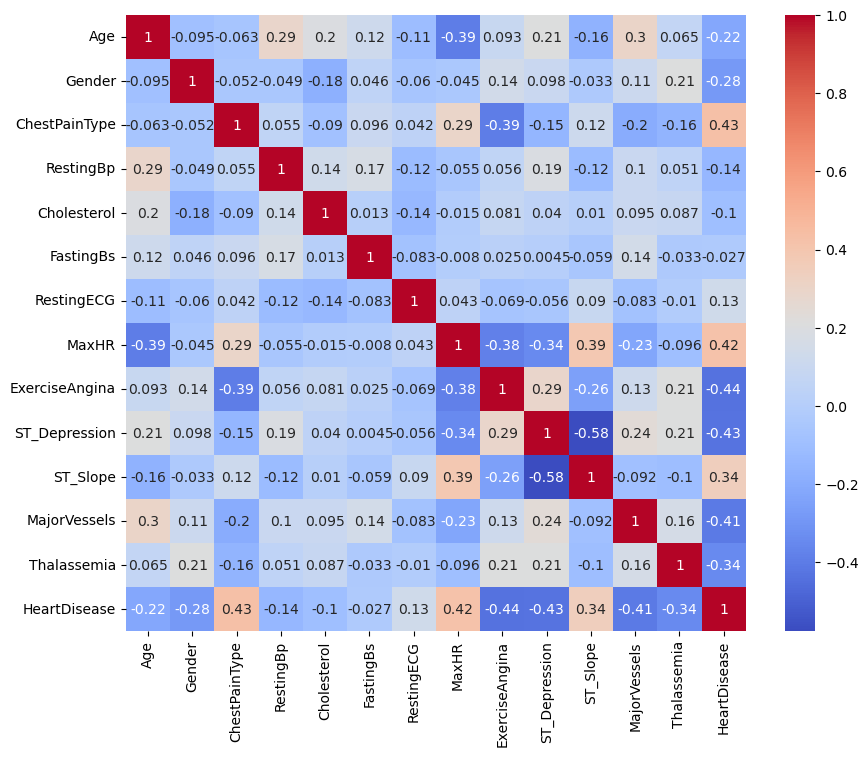

In [8]:
# Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm")
plt.show()

In [9]:
# Separate Features and Target

X=data.drop("HeartDisease",axis=1)

y=data["HeartDisease"]

In [10]:
# Categorical & Numerical Columns

categorical_cols=[
    "Gender",
    "ChestPainType",
    "FastingBs",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "Thalassemia"
]

numerical_cols=[
    "Age",
    "RestingBp",
    "Cholesterol",
    "MaxHR",
    "ST_Depression",
    "MajorVessels"
]

In [11]:
# One Hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X_encoded.head())
print(X_encoded.shape)

    Age  RestingBp  Cholesterol  MaxHR  ST_Depression  MajorVessels  Gender_1  \
0  63.0      145.0        233.0  150.0            2.3             0      True   
1  37.0      130.0        250.0  187.0            3.5             0      True   
2  41.0      130.0        204.0  172.0            1.4             0     False   
3  56.0      120.0        236.0  178.0            0.8             0      True   
4  57.0      120.0        354.0  163.0            0.6             0     False   

   ChestPainType_1  ChestPainType_2  ChestPainType_3  FastingBs_1  \
0            False            False             True         True   
1            False             True            False        False   
2             True            False            False        False   
3             True            False            False        False   
4            False            False            False        False   

   RestingECG_1  RestingECG_2  ExerciseAngina_1  ST_Slope_1  ST_Slope_2  \
0         False        

In [12]:
# Standard Scaling

scaler = StandardScaler()

X_encoded[numerical_cols] = scaler.fit_transform(
    X_encoded[numerical_cols]
)

print(X_encoded.head())

        Age  RestingBp  Cholesterol     MaxHR  ST_Depression  MajorVessels  \
0  0.949794   0.828927    -0.261076  0.017027       1.084022     -0.714911   
1 -1.928548  -0.075902     0.097514  1.644957       2.118926     -0.714911   
2 -1.485726  -0.075902    -0.872787  0.984985       0.307844     -0.714911   
3  0.174856  -0.679121    -0.197795  1.248974      -0.209608     -0.714911   
4  0.285561  -0.679121     2.291236  0.589003      -0.382092     -0.714911   

   Gender_1  ChestPainType_1  ChestPainType_2  ChestPainType_3  FastingBs_1  \
0      True            False            False             True         True   
1      True            False             True            False        False   
2     False             True            False            False        False   
3      True             True            False            False        False   
4     False            False            False            False        False   

   RestingECG_1  RestingECG_2  ExerciseAngina_1  ST_Slop

In [13]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(241, 19)
(61, 19)


In [14]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7868852459016393


In [15]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        28
           1       0.75      0.82      0.78        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



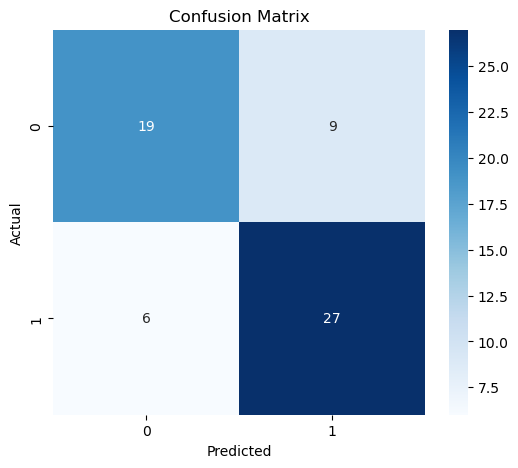

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

                 Model  Accuracy
0  Logistic Regression  0.786885
1        Random Forest  0.754098


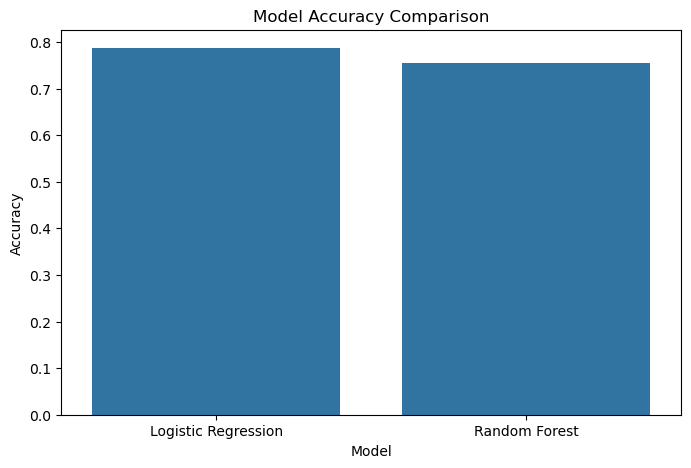

In [17]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy
    ]

})

print(results)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

In [18]:
model_data = {

    "model": rf_model,

    "scaler": scaler,

    "feature_names": X_encoded.columns.tolist(),

    "numerical_cols": numerical_cols,

    "categorical_cols": categorical_cols

}

with open("Heart-Disease-Model.pkl","wb") as file:

    pickle.dump(model_data,file)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [19]:
print("Unique predictions on test set:")
print(np.unique(rf_model.predict(X_test)))

print("Prediction counts:")
print(pd.Series(rf_model.predict(X_test)).value_counts())

Unique predictions on test set:
[0 1]
Prediction counts:
1    36
0    25
Name: count, dtype: int64


In [20]:
print("Train Accuracy:", rf_model.score(X_train, y_train))

print("Test Accuracy:", rf_model.score(X_test, y_test))

print(pd.Series(rf_model.predict(X_test)).value_counts())

print(data["HeartDisease"].value_counts())

Train Accuracy: 1.0
Test Accuracy: 0.7540983606557377
1    36
0    25
Name: count, dtype: int64
HeartDisease
1    164
0    138
Name: count, dtype: int64
